# TUGAS AKHIR

* Nama: Joice Ocrisa 
* NRP: 5003221066

## Harga Saham BBCA

In [15]:
import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

from models.tuning_lstm import train_lstm_tuning
from models import LSTMModel, FEDformer_Model
from utils.data_loader import load_stock_data, prepare_univariate_data
from utils.evaluation import calculate_metrics, plot_predictions, plot_comparison, print_metrics


In [16]:
# Configuration 
BANK_CODE = 'BBCA'  
SEQ_LEN = 30  # Sequence length (look back period)
PRED_LEN = 1  # Prediction length
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = DEVICE
print(f"Using device: {DEVICE}")

Using device: cpu


### Data

In [13]:
# date 
start_date = '2004-06-30'
end_date = '2025-06-30'

# get data
df = load_stock_data(BANK_CODE)
df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)]
print(f"\nUkuran data: {df.shape}")
print("Tanggal awal:", start_date)
print("Tanggal akhir:", end_date)
print("\nBerikut adalah 5 baris pertama data:")
df

c:\Users\User\Documents\AA - TA\tugas-akhir\indonesia-bank-stock-dataset\datasets\BBCA\BBCA.csv

Ukuran data: (5179, 8)
Tanggal awal: 2004-06-30
Tanggal akhir: 2025-06-30

Berikut adalah 5 baris pertama data:


,Close,Date,High,Kode,Low,Nama,Open,Volume
16,187.5,2004-06-30,187.5,BBCA,182.5,Bank Central Asia Tbk.,185.0,291260000.0
17,177.5,2004-07-01,180.0,BBCA,175.0,Bank Central Asia Tbk.,180.0,203090000.0
18,180.0,2004-07-02,180.0,BBCA,177.5,Bank Central Asia Tbk.,177.5,490800000.0
19,180.0,2004-07-05,180.0,BBCA,180.0,Bank Central Asia Tbk.,180.0,0.0
20,187.5,2004-07-06,187.5,BBCA,180.0,Bank Central Asia Tbk.,182.5,826610000.0
...,...,...,...,...,...,...,...,...
5190,8625.0,2025-06-23,8700.0,BBCA,8500.0,Bank Central Asia Tbk.,8575.0,87324500.0
5191,8775.0,2025-06-24,8850.0,BBCA,8700.0,Bank Central Asia Tbk.,8725.0,110158900.0
5192,8600.0,2025-06-25,8775.0,BBCA,8475.0,Bank Central Asia Tbk.,8725.0,117561000.0
5193,8650.0,2025-06-26,8650.0,BBCA,8525.0,Bank Central Asia Tbk.,8525.0,117281700.0


In [4]:
# Missing Value 

missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")
df = df.dropna(subset=['Close'])


Missing values:
Close     0
Date      0
High      0
Kode      0
Low       0
Nama      0
Open      0
Volume    0
dtype: int64


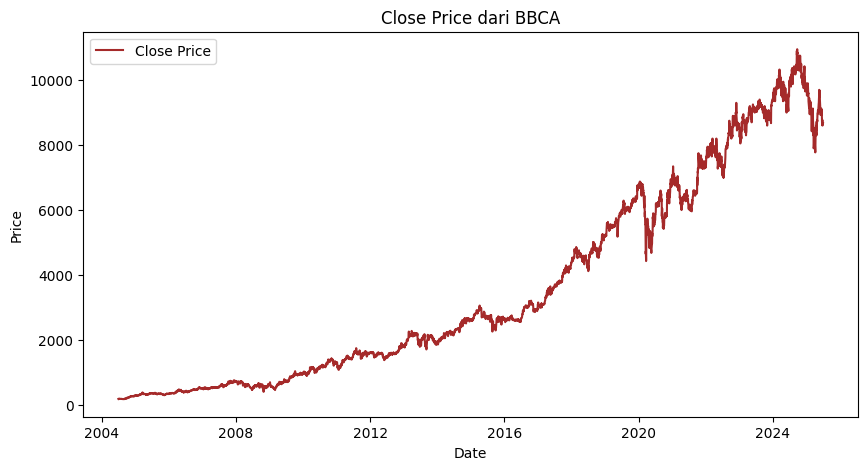

In [5]:
# Time Series Plot

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label = 'Close Price', color = 'brown')
plt.title('Close Price dari ' + BANK_CODE)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [6]:
# Split Data 

X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_univariate_data(df, feature_col='Close', seq_len=SEQ_LEN)
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_val shape: {X_val.shape}, y_val shape: {y_val.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (3604, 30, 1), y_train shape: (3604, 1)
X_val shape: (772, 30, 1), y_val shape: (772, 1)
X_test shape: (773, 30, 1), y_test shape: (773, 1)


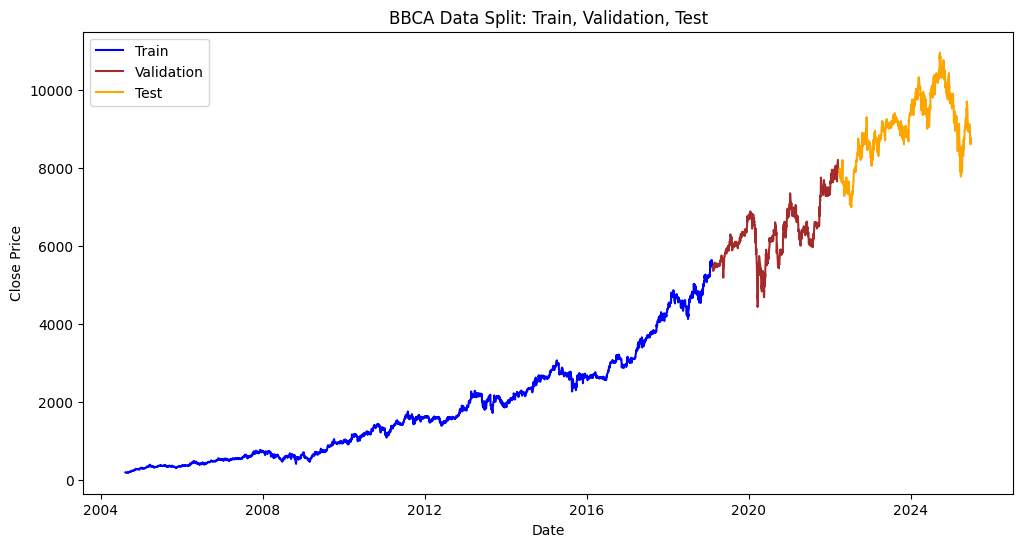

In [7]:
# Plot after split data
Train_size = len(X_train)
Val_size = len(X_val)
Test_size = len(X_test)

Date = df['Date'].values

# Define date for train val and test
idx_train_start = SEQ_LEN - 1
idx_train_end = idx_train_start + Train_size
idx_val_start = idx_train_end 
idx_val_end = idx_val_start + Val_size
idx_test_start = idx_val_end
idx_test_end = idx_test_start + Test_size

train_dates = Date[idx_train_start:idx_train_end]
val_dates = Date[idx_val_start:idx_val_end]
test_dates = Date[idx_test_start:idx_test_end]

# Ensure dates and target lengths match
target_train = y_train[:,0] if y_train.ndim > 1 else y_train
target_val = y_val[:,0] if y_val.ndim > 1 else y_val
target_test = y_test[:,0] if y_test.ndim > 1 else y_test

# Ensure target 1D for plotting
train_inv = scaler.inverse_transform(target_train.reshape(-1, 1)).flatten()
val_inv = scaler.inverse_transform(target_val.reshape(-1, 1)).flatten()
test_inv = scaler.inverse_transform(target_test.reshape(-1, 1)).flatten()

# To avoid if there is a mismatch shape
train_n = min(len(train_dates), len(train_inv))
val_n = min(len(val_dates), len(val_inv))
test_n = min(len(test_dates), len(test_inv))

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(train_dates[:train_n], train_inv[:train_n], label='Train', color='blue')
plt.plot(val_dates[:val_n], val_inv[:val_n], label='Validation', color='brown')
plt.plot(test_dates[:test_n], test_inv[:test_n], label='Test', color='orange')

plt.title(BANK_CODE + ' Data Split: Train, Validation, Test')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [8]:
# Buat data yang sesuai dengan Data Loader
class stockdataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = stockdataset(X_train, y_train)
val_dataset = stockdataset(X_val, y_val)    
test_dataset = stockdataset(X_test, y_test)

# Gunakan DataLoader untuk batching
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)    

## **LSTM Model**

### Train-Validation LSTM 

In [9]:
# # LSTMModel 
# lstm_model = LSTMModel(
#     input_size = 1, 
#     hidden_size=64, 
#     num_layers = 2, 
#     output_size = PRED_LEN, 
#     dropout=0.2
# ).to(DEVICE)
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

# # menurunkan learning rate secara bertahap selama training
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# # training loop
# train_losses = []
# val_losses = []

# for epoch in range(EPOCHS):
#     lstm_model.train()
#     train_loss = 0.0
#     for X_batch, y_batch in train_loader:
#         # X_batch = X_batch.to(DEVICE)
#         # y_batch = y_batch.to(DEVICE)
#         optimizer.zero_grad()
#         outputs = lstm_model(X_batch)

#         loss = criterion(outputs, y_batch)
#         loss.backward()

#         optimizer.step()
#         train_loss += loss.item() * X_batch.size(0)
    
#     lstm_model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for X_batch, y_batch in val_loader:
#             outputs = lstm_model(X_batch)
#             loss = criterion(outputs, y_batch)
#             val_loss += loss.item() * X_batch.size(0)
    
#     train_loss /= len(train_loader.dataset)
#     val_loss /= len(val_loader.dataset)
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)

#     scheduler.step(val_loss)

#     if (epoch+1) % 10 == 0 or epoch == 0:
#         print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# print("LSTM Training Complete!")

### Tuning Hyperparameter LSTM

In [10]:
# List Hyperparameter
dropout_list = [0.1, 0.2, 0.3]
lr_list = [1e-1, 1e-2, 1e-3]
batch_size_list = [32, 64, 128]

In [11]:
# import itertools

# results = []

# for dropout, lr, batch_size in itertools.product(
#         dropout_list, lr_list, batch_size_list):

#     val_loss = train_lstm_tuning(dropout, lr, batch_size, train_dataset, val_dataset, DEVICE)
#     results.append({
#         'dropout': dropout,
#         'learning_rate': lr,
#         'batch_size': batch_size,
#         'val_loss': val_loss
#     })
#     print(f"Dropout={dropout}, LR={lr}, Batch={batch_size}, Val Loss={val_loss:.6f}")

# best_config = min(results, key=lambda x: x['val_loss'])

# print("\n\nBest Hyperparameter Configuration:")
# print(best_config)

### Training Validation with Best Hyperparameter

In [12]:
SEQ_LEN = 30  
PRED_LEN = 1  
EPOCHS = 100 
BATCH_SIZE = 32
LEARNING_RATE = 0.001
dropout = 0.2

# LSTMModel 
lstm_model = LSTMModel(
    input_size = 1, 
    hidden_size=64, 
    num_layers = 2, 
    output_size = PRED_LEN, 
    dropout=dropout
).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# training loop
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)
        loss.backward()

        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = lstm_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("LSTM Training Complete!")

Epoch [1/100] | Train Loss: 0.006787 | Val Loss: 0.000523
Epoch [2/100] | Train Loss: 0.000114 | Val Loss: 0.000775
Epoch [3/100] | Train Loss: 0.000111 | Val Loss: 0.000854
Epoch [4/100] | Train Loss: 0.000096 | Val Loss: 0.000558
Epoch [5/100] | Train Loss: 0.000106 | Val Loss: 0.000536
Epoch [6/100] | Train Loss: 0.000110 | Val Loss: 0.000532
Epoch [7/100] | Train Loss: 0.000089 | Val Loss: 0.001047
Epoch [8/100] | Train Loss: 0.000068 | Val Loss: 0.000777
Epoch [9/100] | Train Loss: 0.000081 | Val Loss: 0.000823
Epoch [10/100] | Train Loss: 0.000068 | Val Loss: 0.000588
Epoch [11/100] | Train Loss: 0.000068 | Val Loss: 0.000776
Epoch [12/100] | Train Loss: 0.000059 | Val Loss: 0.000502
Epoch [13/100] | Train Loss: 0.000061 | Val Loss: 0.000624
Epoch [14/100] | Train Loss: 0.000063 | Val Loss: 0.000595
Epoch [15/100] | Train Loss: 0.000063 | Val Loss: 0.000496
Epoch [16/100] | Train Loss: 0.000057 | Val Loss: 0.000628
Epoch [17/100] | Train Loss: 0.000058 | Val Loss: 0.000580
Epoch 

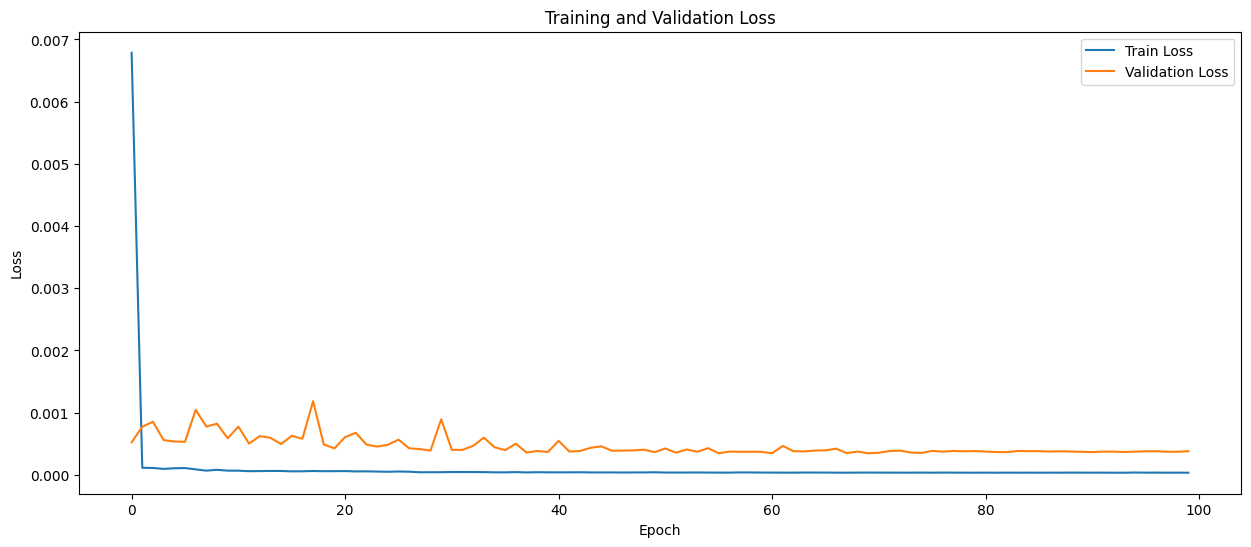

In [13]:
# Plot training and validation loss
plt.figure(figsize=(15, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### Evaluasi Model

In [14]:
# Pengujian Model 
lstm_model.eval()

lstm_predictions = []
y_true_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        lstm_out = lstm_model(X_batch)
        lstm_out = lstm_out.cpu().numpy().flatten()

        lstm_predictions.append(lstm_out)
        y_true_list.append(y_batch.cpu().numpy().flatten())

lstm_pred = np.concatenate(lstm_predictions)
y_true = np.concatenate(y_true_list)

if scaler is not None:
    lstm_pred = scaler.inverse_transform(
        lstm_pred.reshape(-1, 1)
    ).flatten()

    y_true = scaler.inverse_transform(
        y_true.reshape(-1, 1)
    ).flatten()

In [15]:
# Calculate metrics
lstm_metrics = calculate_metrics(y_true, lstm_pred)

print_metrics(lstm_metrics, "LSTM")


LSTM Metrics:
----------------------------------------
MAE       : 441.5445
MSE       : 248793.3125
RMSE      : 498.7919
MAPE      : 4.7408%
R2        : 0.6425
----------------------------------------


## **FEDformer Model**

### Train-Validation FEDformer

In [16]:
from models import LSTMModel, FEDformer_Model


In [9]:
from models import LSTMModel, FEDformer_Model

class Configs(object):
    ab = 0
    modes = 32
    mode_select = 'random'
    moving_avg = [12, 24]

    seq_len = SEQ_LEN
    label_len = SEQ_LEN // 2
    pred_len = PRED_LEN

    output_attention = False

    enc_in = 1
    dec_in = 1
    c_out = 1

    d_model = 128
    embed_type = 'timeF'
    dropout = 0.1
    freq = 'h'
    factor = 1
    n_heads = 8
    d_ff = 512
    e_layers = 2
    d_layers = 1
    activation = 'gelu'

configs = Configs()
model = FEDformer_Model(configs).to(DEVICE)


fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
fourier enhanced block used!
modes=32, index=[0, 1, 2, 3, 4, 5, 6, 7]
 fourier enhanced cross attention used!
modes_q=8, index_q=[0, 1, 2, 3, 4, 5, 6, 7]
modes_kv=15, index_kv=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
enc_modes: 15, dec_modes: 8


In [14]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

best_val_loss = float('inf')
patience = 5
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # ===================== TRAIN =====================
    model.train()
    train_loss = 0.0

    for x_enc, y_true in train_loader:
        x_enc = x_enc.to(DEVICE)
        y_true = y_true.to(DEVICE)

        B, _, C = x_enc.shape
        device = x_enc.device

        x_dec = torch.zeros(
            B,
            configs.label_len + configs.pred_len,
            C,
            device=device
        )

        x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=device)
        x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=device)

        optimizer.zero_grad()

        outputs = model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )

        if y_true.dim() == 2:
            y_true = y_true.unsqueeze(-1)

        loss = criterion(outputs, y_true)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)   

    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x_enc, y_true in val_loader:
            x_enc = x_enc.to(DEVICE)
            y_true = y_true.to(DEVICE)

            B, _, C = x_enc.shape

            x_dec = torch.zeros(
                B,
                configs.label_len + configs.pred_len,
                C,
                device=DEVICE
            )

            x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=DEVICE)
            x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=DEVICE)

            outputs = model(
                x_enc,
                x_mark_enc,
                x_dec,
                x_mark_dec
            )

            if y_true.dim() == 2:
                y_true = y_true.unsqueeze(-1)

            loss = criterion(outputs, y_true)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)       

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    # ===================== EARLY STOPPING =====================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_fedformer.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load("best_fedformer.pth", map_location=DEVICE))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (960x4 and 3x128)

In [ ]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('FEDFormer Training History', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Evaluasi Model

In [ ]:
model.eval()

y_true_all = []
y_pred_all = []

with torch.no_grad():
    for x_enc, y_true in test_loader:
        x_enc = x_enc.to(DEVICE)
        y_true = y_true.to(DEVICE)

        B, _, C = x_enc.shape

        # decoder dummy input (sesuai FEDformer resmi)
        x_dec = torch.zeros(
            B,
            configs.label_len + configs.pred_len,
            C,
            device=DEVICE
        )
        x_mark_enc = torch.zeros(B, configs.seq_len, 4, device=DEVICE)
        x_mark_dec = torch.zeros(B, configs.label_len + configs.pred_len, 4, device=DEVICE)

        outputs = model(
            x_enc,
            x_mark_enc,
            x_dec,
            x_mark_dec
        )  # [B, pred_len, c_out]

        if y_true.dim() == 2:
            y_true = y_true.unsqueeze(-1)

        y_true_all.append(y_true.cpu().numpy())
        y_pred_all.append(outputs.cpu().numpy())


In [ ]:
y_true_all = np.concatenate(y_true_all, axis=0)  # [N, pred_len, c_out]
y_pred_all = np.concatenate(y_pred_all, axis=0)

y_true_flat = y_true_all.reshape(-1)
y_pred_flat = y_pred_all.reshape(-1)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_true_flat, y_pred_flat)
mse = mean_squared_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mse)
r2 = r2_score(y_true_flat, y_pred_flat)

# MAPE (aman dari division by zero)
epsilon = 1e-8
mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + epsilon))) * 100


print("FEDFormer Metrics:")
print("----------------------------------------")
print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"MAPE      : {mape:.4f}%")
print(f"R2        : {r2:.4f}")
print("----------------------------------------")



### Plot Perbandingan

In [ ]:
# Plot comparison
plot_comparison(
    y_true,
    lstm_pred,
    fedformer_pred,
    title=f"Univariate Prediction Comparison - {BANK_CODE}",
    save_path=f"../results/{BANK_CODE}_comparison.png",
    show_plot=True
)